# Customer 360 — SaaS Product Adoption, Retention & Revenue Analytics
One unified customer view: how customers adopt, why they stay or leave, and what they're worth.

**Data:** five CSV datasets in `data_csv/` — 500,000 B2B SaaS customers tracked monthly from Jan-2023 to Dec-2024 (seeded synthetic data; patterns such as support-pain → churn are engineered into the generator).
No data is generated inside this notebook — every cell below loads the CSVs and analyses them step by step.

**Run:** Kernel → Restart & Run All (about 10 minutes). All charts render inline; key tables are also saved to `outputs/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # works from project root or notebooks/
    ROOT = ROOT.parent
CSV = ROOT / "data_csv"          # <-- the CSV datasets
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

M = 24                           # months: Jan-2023 .. Dec-2024
CAL = pd.period_range("2023-01", periods=M, freq="M")
FEATS = ["dashboard", "reports", "integrations", "api",
         "collaboration", "alerts", "mobile", "admin"]
FCOLS = [f"f_{f}" for f in FEATS]

pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110})
print("datasets:", sorted(p.name for p in CSV.glob("*.csv.gz")))

datasets: ['customers.csv.gz', 'invoices.csv.gz', 'product_events.csv.gz', 'subscriptions.csv.gz', 'support_tickets.csv.gz']


## 1 · Load the datasets
Five tables, one row per customer-month (except `customers`, one row per customer).

In [2]:
customers   = pd.read_csv(CSV / "customers.csv.gz")
subscriptions = pd.read_csv(CSV / "subscriptions.csv.gz")
events        = pd.read_csv(CSV / "product_events.csv.gz")
invoices      = pd.read_csv(CSV / "invoices.csv.gz")
tickets       = pd.read_csv(CSV / "support_tickets.csv.gz")

tables = {"customers": customers, "subscriptions": subscriptions,
          "product_events": events, "invoices": invoices,
          "support_tickets": tickets}
for name, df in tables.items():
    print(f"{name:15s} {df.shape[0]:>10,} rows x {df.shape[1]:>2} cols")

# CSVs don't preserve pandas categoricals -> restore the exact dtypes/orders
# from the pipeline so groupbys sort and get_dummies(drop_first) match it
for col, cats in {
        "plan_initial": ["Starter", "Growth", "Scale", "Enterprise"],
        "channel": ["Organic", "Paid", "Partner", "Referral", "Sales"],
        "region": ["APAC", "EU", "LATAM", "NA"],
        "company_size": ["Enterprise", "Mid-Market", "SMB"],
        "industry": ["Finance", "Healthcare", "Manufacturing", "Other", "Retail", "Tech"]}.items():
    customers[col] = pd.Categorical(customers[col], categories=cats, ordered=True)
subscriptions["plan"] = pd.Categorical(
    subscriptions["plan"], categories=["Enterprise", "Growth", "Scale", "Starter"], ordered=True)
invoices["status"] = pd.Categorical(
    invoices["status"], categories=["paid", "late", "unpaid"], ordered=True)
tickets["category"] = pd.Categorical(
    tickets["category"],
    categories=["Billing", "Bug", "Feature request", "How-to", "Performance"], ordered=True)
tickets["priority"] = pd.Categorical(
    tickets["priority"], categories=["Critical", "High", "Low", "Medium"], ordered=True)
print("categoricals restored:", customers["plan_initial"].dtype)

customers          500,000 rows x 13 cols
subscriptions    3,655,754 rows x  5 cols
product_events   3,655,754 rows x 14 cols
invoices         3,655,754 rows x  6 cols
support_tickets    767,073 rows x  6 cols


categoricals restored: category


In [3]:
customers.head(3).T

,0,1,2
customer_id,1,2,3
signup_date,2023-12-14,2024-02-10,2023-07-19
signup_m,11,13,6
plan_initial,Starter,Starter,Starter
channel,Paid,Organic,Organic
region,EU,NaN,APAC
industry,Finance,Manufacturing,Manufacturing
company_size,Mid-Market,SMB,SMB
engagement_tier,Casual,Power,Regular
mrr_mult,0.964578,1.024276,0.98694


## 2 · Validate data quality
Trust-but-verify before any analysis: nulls, duplicate customer-months, orphaned foreign keys, and impossible values.

In [4]:
for name, df in tables.items():
    print(f"{name:15s} null cells: {df.isna().sum().sum()}")

for name, df in [("subscriptions", subscriptions), ("product_events", events)]:
    print(name, "duplicate customer-months:",
          df.duplicated(["customer_id", "month_idx"]).sum())

cids = set(customers["customer_id"])
for name, df in tables.items():
    if name == "customers":
        continue
    print(name, "orphan customer_ids:",
          (~df["customer_id"].isin(cids)).sum())

customers       null cells: 224508


subscriptions   null cells: 0
product_events  null cells: 0
invoices        null cells: 0
support_tickets null cells: 0


subscriptions duplicate customer-months: 0


product_events duplicate customer-months: 0
subscriptions orphan customer_ids: 0


product_events orphan customer_ids: 0
invoices orphan customer_ids: 0
support_tickets orphan customer_ids: 0


In [5]:
sm = customers.set_index("customer_id")["signup_m"]
lam = customers.set_index("customer_id")["last_active_m"]
print("event months before signup:", (events["month_idx"] < events["customer_id"].map(sm)).sum())
print("event months after last active:", (events["month_idx"] > events["customer_id"].map(lam)).sum())
print("non-positive MRR rows:", (subscriptions["mrr"] <= 0).sum())
print("CSAT outside 1-5:", ((tickets["csat"] < 1) | (tickets["csat"] > 5)).sum())
print("non-positive invoice amounts:", (invoices["amount"] <= 0).sum())
dim = pd.Series({m: p.days_in_month for m, p in enumerate(CAL)})
print("login_days > days_in_month:", (events["login_days"] > events["month_idx"].map(dim)).sum())
print("invoice status mix:\n", invoices["status"].value_counts(normalize=True).round(3))

event months before signup: 0
event months after last active: 0
non-positive MRR rows: 0
CSAT outside 1-5: 0
non-positive invoice amounts: 0
login_days > days_in_month: 0
invoice status mix:
 status
paid      0.925
late      0.051
unpaid    0.023
Name: proportion, dtype: float64


## 3 · Build the Customer 360 table
Collapse the monthly grain to **one row per customer**. We build it in four visible steps so every feature family can be inspected: identity + tenure, usage, activation, then revenue / support / billing.

### 3a · Identity, tenure, current plan

In [6]:
c360 = customers[["customer_id", "signup_date", "signup_m", "plan_initial",
                  "channel", "region", "industry", "company_size",
                  "engagement_tier", "churned", "churn_m",
                  "last_active_m"]].copy()
c360["tenure_months"] = (c360["last_active_m"] - c360["signup_m"] + 1).clip(lower=0)

# current plan / MRR = the customer's last subscription row
last_sub = subscriptions.sort_values("month_idx").groupby("customer_id").tail(1)
c360 = c360.merge(last_sub[["customer_id", "plan", "mrr"]]
                  .rename(columns={"plan": "plan_current", "mrr": "mrr_current"}),
                  on="customer_id", how="left")
print(c360.shape)
c360[["plan_initial", "churned", "tenure_months"]].head(3)

(500000, 15)


,plan_initial,churned,tenure_months
0,Starter,True,2
1,Starter,True,6
2,Starter,True,0


### 3b · Usage features — level, trend, stickiness, time-to-value

In [7]:
u = events.groupby("customer_id").agg(
    n_active_months=("month_idx", "size"),
    avg_login_days=("login_days", "mean"),
    avg_sessions=("sessions", "mean"),
    max_login_days=("login_days", "max"),
    std_login_days=("login_days", "std"),
    feature_breadth=("n_features", "max"),
    avg_features=("n_features", "mean"),
)
# stickiness ~= active_days / days_in_month, averaged over active months
u["stickiness"] = (events.assign(stick=events["active_days"] / events["month_idx"].map(dim))
                   .groupby("customer_id")["stick"].mean())

def slope_last6(g):
    y = g.sort_values("month_idx")["login_days"].to_numpy(dtype=float)[-6:]
    return 0.0 if len(y) < 2 else float(np.polyfit(np.arange(len(y)), y, 1)[0])
u["usage_trend"] = events.groupby("customer_id")[["month_idx", "login_days"]].apply(slope_last6)

# time-to-value: first month with >= 12 sessions (monthly grain -> days approx)
first_val = events[events["sessions"] >= 12].groupby("customer_id")["month_idx"].min()
c360["ttv_days"] = (first_val - sm).reindex(c360["customer_id"]).to_numpy() * 30 + 15

c360 = c360.merge(u, on="customer_id", how="left")
print(u.shape)
u[["avg_login_days", "stickiness", "usage_trend", "feature_breadth"]].describe().round(2)

(455911, 9)


,avg_login_days,stickiness,usage_trend,feature_breadth
count,455911.00,455911.00,455911.00,455911.00
mean,12.62,0.41,0.01,3.93
std,6.39,0.21,1.34,1.75
min,0.00,0.00,-14.00,0.00
25%,7.18,0.24,-0.46,3.00
50%,13.47,0.44,0.00,4.00
75%,15.75,0.52,0.46,5.00
max,31.00,1.00,15.00,8.00


### 3c · Activation flag — ≥4 login days in the signup month AND ≥2 features touched in the first two months

In [8]:
m0 = events[events["month_idx"] == events["customer_id"].map(sm)]
act_m0 = m0.groupby("customer_id")["login_days"].max() >= 4
m01 = events[events["month_idx"] <= events["customer_id"].map(sm) + 1]
feat01 = m01.groupby("customer_id")[FCOLS].max().sum(axis=1) >= 2
c360["activated"] = (c360["customer_id"].map(act_m0).fillna(False)
                     & c360["customer_id"].map(feat01).fillna(False))

print(f"activation rate: {c360['activated'].mean():.1%}")
print(c360.groupby("plan_initial", observed=True)["activated"].mean().round(3))

activation rate: 76.4%
plan_initial
Starter       0.699
Growth        0.839
Scale         0.900
Enterprise    0.936
Name: activated, dtype: float64


/tmp/ipykernel_5812/1323738160.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c360["activated"] = (c360["customer_id"].map(act_m0).fillna(False)
/tmp/ipykernel_5812/1323738160.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & c360["customer_id"].map(feat01).fillna(False))


### 3d · Revenue, support and billing features, then save

In [9]:
r = subscriptions.groupby("customer_id").agg(
    lifetime_revenue=("mrr", "sum"),
    mrr_initial=("mrr", "first"),
    months_billed=("mrr", "size"))
s = subscriptions.sort_values(["customer_id", "month_idx"])
s["delta"] = s.groupby("customer_id")["mrr"].diff().fillna(0)
r["expansion_mrr"] = s[s["delta"] > 0].groupby("customer_id")["delta"].sum()
r["contraction_mrr"] = -s[s["delta"] < 0].groupby("customer_id")["delta"].sum()
c360 = c360.merge(r, on="customer_id", how="left")
c360[["expansion_mrr", "contraction_mrr"]] = c360[["expansion_mrr", "contraction_mrr"]].fillna(0)

t = tickets.groupby("customer_id").agg(
    n_tickets=("category", "size"),
    avg_resolution_days=("resolution_days", "mean"),
    avg_csat=("csat", "mean"),
    high_priority_share=("priority", lambda x: x.isin(["High", "Critical"]).mean()))
c360 = c360.merge(t, on="customer_id", how="left")
c360[["n_tickets"]] = c360[["n_tickets"]].fillna(0)

b = invoices.groupby("customer_id").agg(
    unpaid_share=("status", lambda x: (x == "unpaid").mean()),
    late_share=("status", lambda x: (x == "late").mean()))
c360 = c360.merge(b, on="customer_id", how="left")

c360["recency_months"] = (M - 1) - c360["last_active_m"]
for col in ["avg_login_days", "avg_sessions", "stickiness", "feature_breadth",
            "avg_features", "usage_trend", "n_active_months", "max_login_days"]:
    c360[col] = c360[col].fillna(0)

c360.to_parquet(OUT / "customer360.parquet", index=False)
print(f"customer360: {c360.shape[0]:,} customers x {c360.shape[1]} features")
print("churned:", f"{c360['churned'].mean():.2%}",
      "| activated:", f"{c360['activated'].mean():.2%}")

customer360: 500,000 customers x 38 features
churned: 43.20% | activated: 76.40%


## 4 · Adoption analysis
Where does the signup-to-value funnel leak, and which features actually get used?

            stage  customers  conv_from_signup
        Signed up     500000          1.000000
  Activated (60d)     381976          0.763952
Active in month 2     404585          0.809170
Active in month 6     252063          0.504126


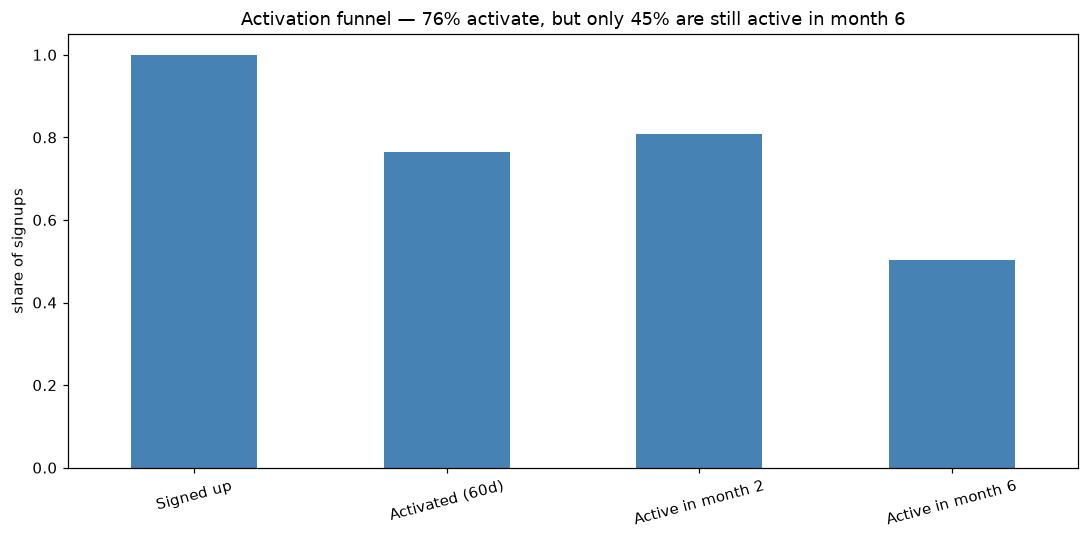

In [10]:
funnel = pd.DataFrame({
    "stage": ["Signed up", "Activated (60d)", "Active in month 2", "Active in month 6"],
    "customers": [len(c360), c360["activated"].sum(),
                  (events.merge(customers[["customer_id", "signup_m"]], on="customer_id")
                   .query("month_idx == signup_m + 1")["customer_id"].nunique()),
                  (events.merge(customers[["customer_id", "signup_m"]], on="customer_id")
                   .query("month_idx == signup_m + 5")["customer_id"].nunique())]})
funnel["conv_from_signup"] = funnel["customers"] / len(c360)
print(funnel.to_string(index=False))

ax = funnel.plot.bar(x="stage", y="conv_from_signup", legend=False, color="steelblue")
ax.set_ylabel("share of signups"); ax.set_xlabel("")
ax.set_title("Activation funnel — 76% activate, but only 45% are still active in month 6")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

activation by plan:
 plan_initial
Starter       0.699
Growth        0.839
Scale         0.900
Enterprise    0.936
Name: activated, dtype: float64

activation by channel:
 channel
Organic     0.765
Paid        0.745
Partner     0.765
Referral    0.781
Sales       0.776
Name: activated, dtype: float64


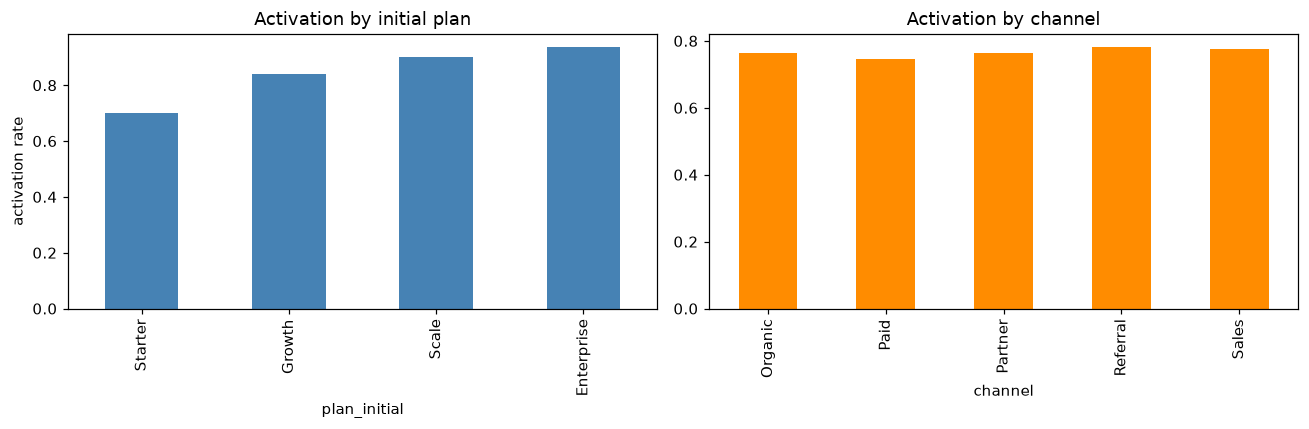

In [11]:
act_plan = c360.groupby("plan_initial", observed=True)["activated"].mean().round(3)
act_chan = c360.groupby("channel", observed=True)["activated"].mean().round(3)
print("activation by plan:\n", act_plan)
print("\nactivation by channel:\n", act_chan)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
act_plan.plot.bar(ax=ax[0], color="steelblue"); ax[0].set_title("Activation by initial plan")
ax[0].set_ylabel("activation rate")
act_chan.plot.bar(ax=ax[1], color="darkorange"); ax[1].set_title("Activation by channel")
plt.tight_layout(); plt.show()

              dashboard  reports  integrations    api  collaboration  alerts  \
plan_initial                                                                   
Starter           0.817    0.353         0.055  0.025          0.252   0.156   
Growth            0.840    0.621         0.155  0.091          0.433   0.341   
Scale             0.864    0.790         0.379  0.340          0.610   0.561   
Enterprise        0.874    0.852         0.546  0.636          0.733   0.684   

              mobile  admin  
plan_initial                 
Starter        0.293  0.106  
Growth         0.381  0.252  
Scale          0.467  0.524  
Enterprise     0.504  0.775  


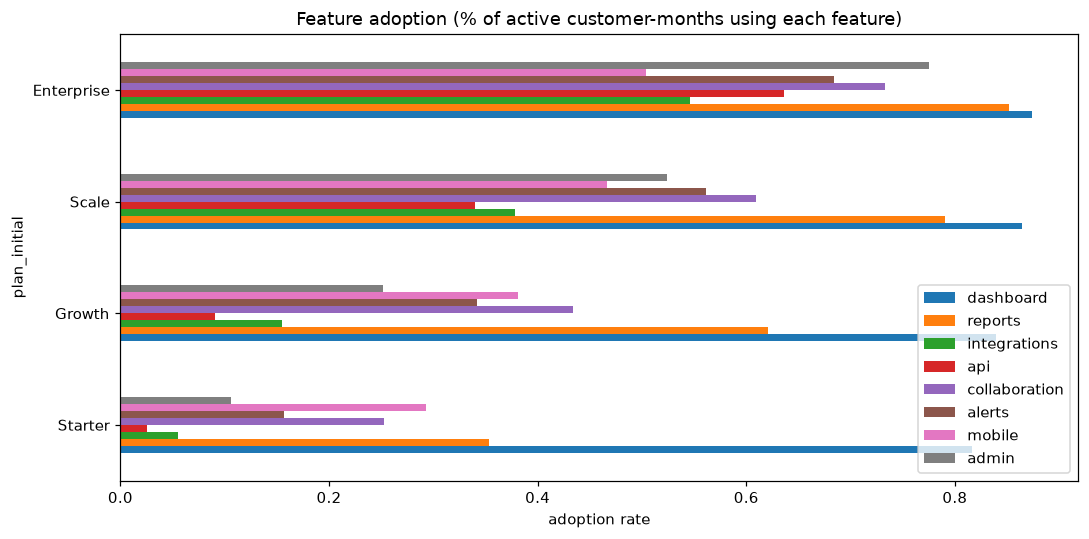

In [12]:
evp = events.merge(customers[["customer_id", "plan_initial"]], on="customer_id")
feat_adopt = evp.groupby("plan_initial", observed=True)[FCOLS].mean()
feat_adopt.columns = FEATS
print((feat_adopt).round(3))
feat_adopt.plot.barh(figsize=(10, 5))
plt.title("Feature adoption (% of active customer-months using each feature)")
plt.xlabel("adoption rate"); plt.tight_layout(); plt.show()

median TTV: 15 days | mean: 19 days | never reached value: 16.3%


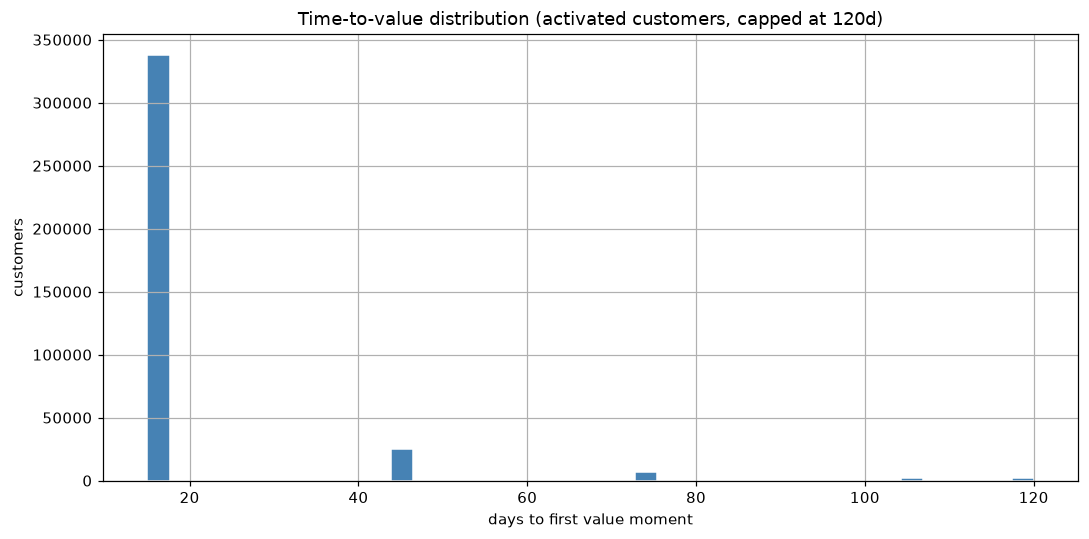

In [13]:
ttv = c360.loc[c360["activated"], "ttv_days"]
print(f"median TTV: {ttv.median():.0f} days | mean: {ttv.mean():.0f} days | "
      f"never reached value: {c360['ttv_days'].isna().mean():.1%}")
ttv.clip(upper=120).hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Time-to-value distribution (activated customers, capped at 120d)")
plt.xlabel("days to first value moment"); plt.ylabel("customers")
plt.tight_layout(); plt.show()

## 5 · Retention analysis
How long do customers stay? Cohort curves, survival analysis, and the churn calendar.

avg retention @ month 1: 85.1%
avg retention @ month 3: 75.6%
avg retention @ month 6: 64.6%
avg retention @ month 12: 48.5%


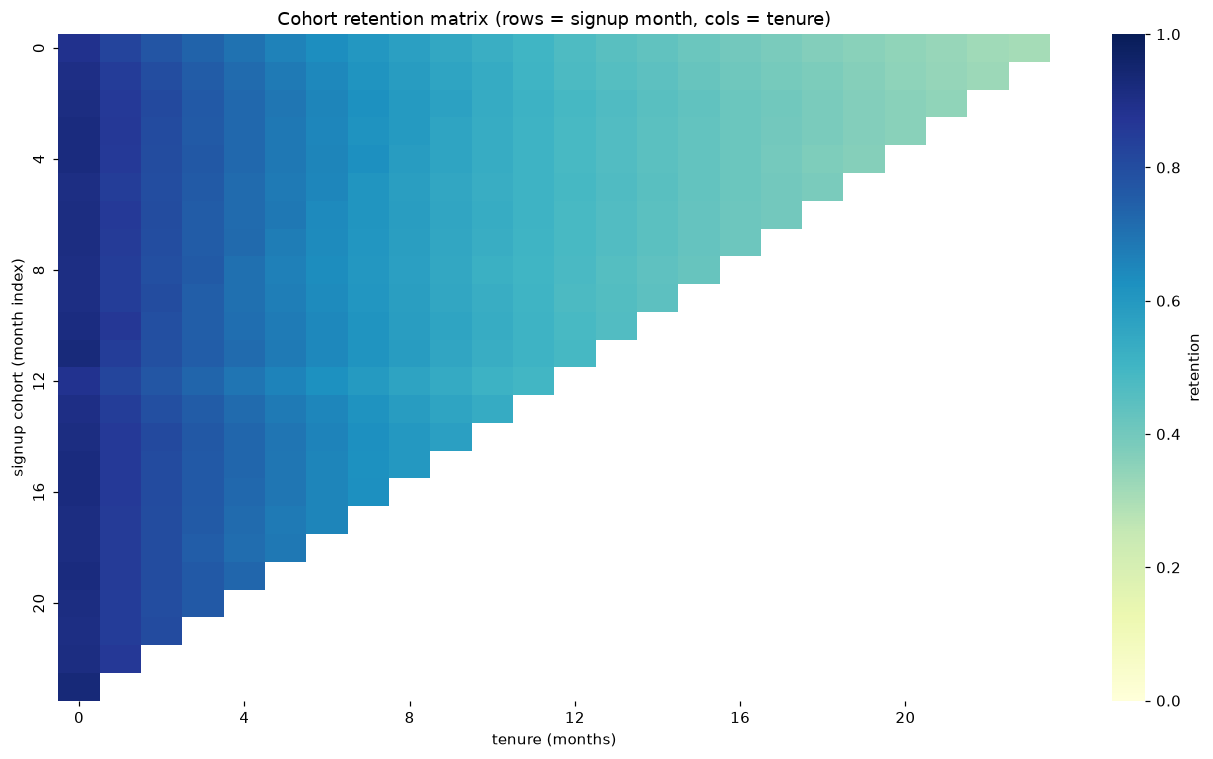

In [14]:
def cohort_retention(events, customers, max_tenure=23):
    """Rows = signup cohort, cols = tenure month. Future (unobservable) cells -> NaN."""
    act = events[["customer_id", "month_idx"]].drop_duplicates()
    act = act.merge(customers[["customer_id", "signup_m"]], on="customer_id")
    act["tenure"] = act["month_idx"] - act["signup_m"]
    act = act[(act["tenure"] >= 0) & (act["tenure"] <= max_tenure)]
    size = customers.groupby("signup_m")["customer_id"].nunique()
    mat = act.groupby(["signup_m", "tenure"])["customer_id"].nunique().unstack(fill_value=0)
    mat = mat.div(size, axis=0).round(4)
    # mask tenures no cohort has lived long enough to reach
    max_obs = (M - 1) - mat.index.to_numpy()[:, None]
    mat = mat.mask(np.arange(mat.shape[1])[None, :] > max_obs)
    return mat

mat = cohort_retention(events, customers)
mat.to_csv(OUT / "cohort_retention.csv")
avg_curve = mat.mean(axis=0, skipna=True)
for t in [1, 3, 6, 12]:
    print(f"avg retention @ month {t}: {avg_curve.get(t, float('nan')):.1%}")

plt.figure(figsize=(12, 7))
sns.heatmap(mat, cmap="YlGnBu", vmin=0, vmax=1,
            xticklabels=4, yticklabels=4, cbar_kws={"label": "retention"})
plt.title("Cohort retention matrix (rows = signup month, cols = tenure)")
plt.xlabel("tenure (months)"); plt.ylabel("signup cohort (month index)")
plt.tight_layout(); plt.show()

RETENTION @ M12 BY PLAN
 plan_initial
Starter       0.391
Growth        0.561
Scale         0.715
Enterprise    0.855


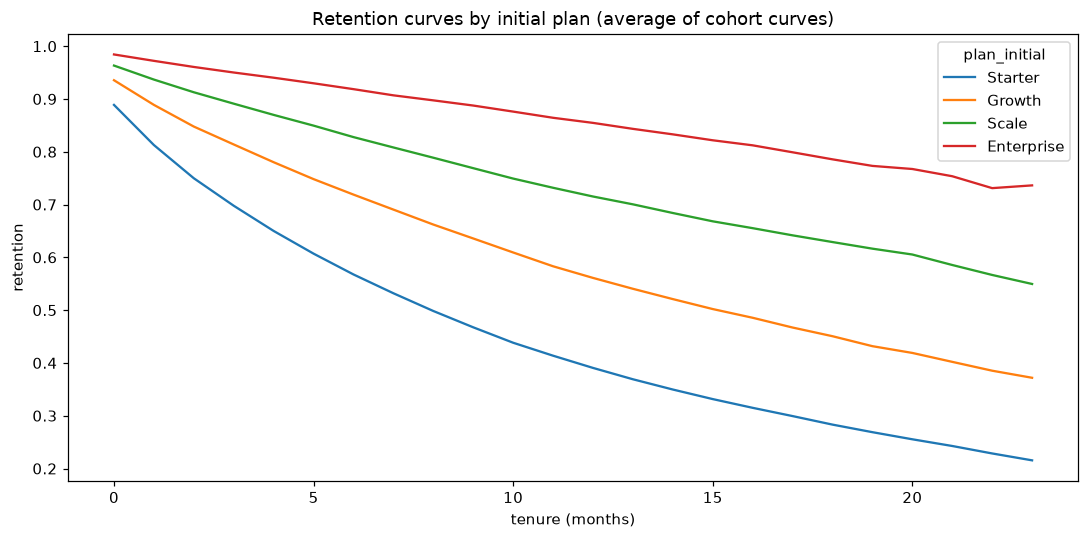

In [15]:
evc = events.merge(customers[["customer_id", "plan_initial", "signup_m"]], on="customer_id")
evc["tenure"] = evc["month_idx"] - evc["signup_m"]
cs = customers.groupby(["signup_m", "plan_initial"], observed=True)["customer_id"].nunique()
r = (evc.groupby(["signup_m", "plan_initial", "tenure"], observed=True)["customer_id"]
     .nunique().div(cs).groupby(["plan_initial", "tenure"], observed=True).mean().unstack("tenure"))
r.to_csv(OUT / "retention_by_plan.csv")
print("RETENTION @ M12 BY PLAN\n", r[12].round(3).to_string())

r.T.plot(figsize=(10, 5))
plt.title("Retention curves by initial plan (average of cohort curves)")
plt.xlabel("tenure (months)"); plt.ylabel("retention")
plt.tight_layout(); plt.show()

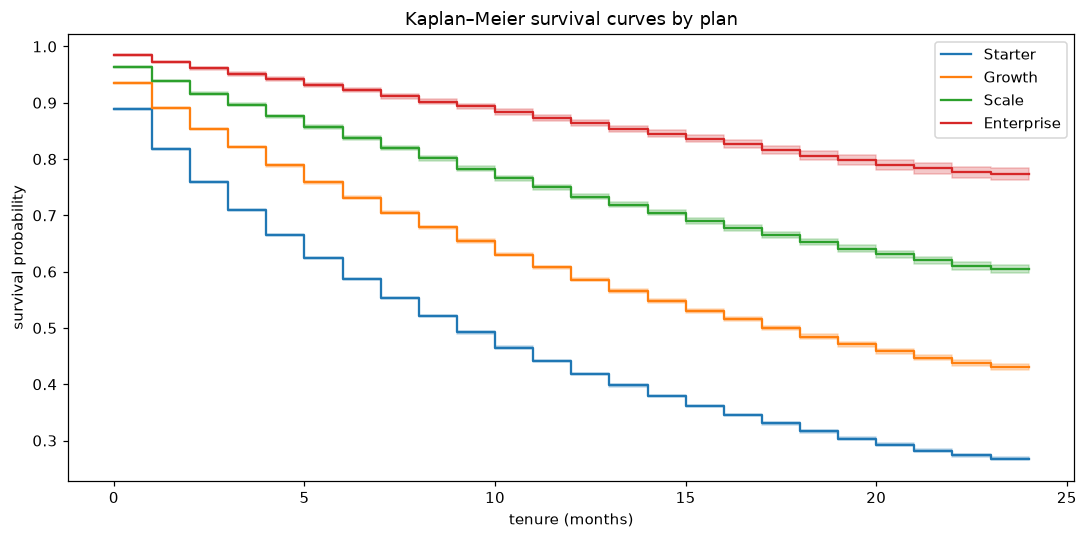

median survival (months):
Starter        9.0
Growth        17.0
Scale          inf
Enterprise     inf


In [16]:
from lifelines import KaplanMeierFitter
kmf, medians = KaplanMeierFitter(), {}
plt.figure(figsize=(10, 5))
for plan in ["Starter", "Growth", "Scale", "Enterprise"]:
    sub = customers[customers["plan_initial"] == plan]
    T = (sub["last_active_m"] - sub["signup_m"] + 1).clip(lower=0)
    kmf.fit(T, sub["churned"].astype(int), label=plan)
    medians[plan] = kmf.median_survival_time_
    kmf.plot_survival_function()
plt.title("Kaplan–Meier survival curves by plan")
plt.xlabel("tenure (months)"); plt.ylabel("survival probability")
plt.tight_layout(); plt.show()
print("median survival (months):")
print(pd.Series(medians).round(1).to_string())

avg monthly logo churn: 6.50% (min 4.59%, max 12.64%)


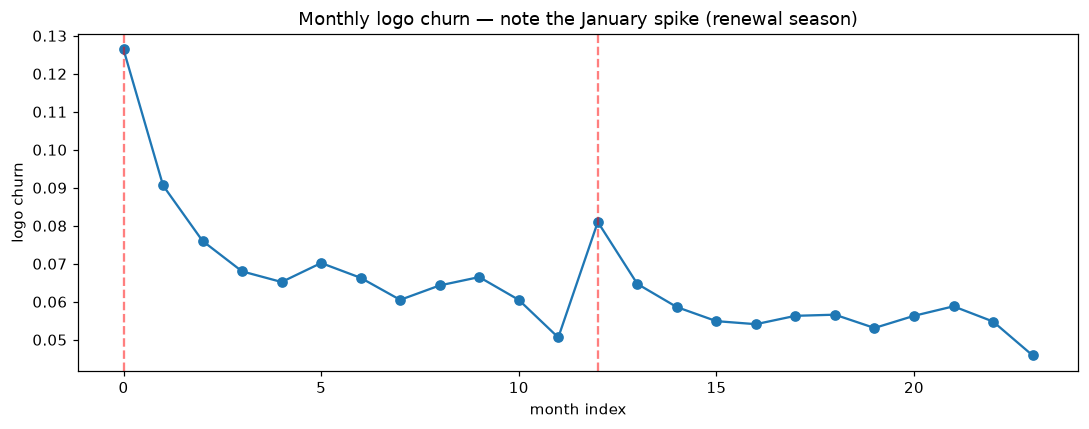

January logo churn: 10.4% vs other months: 6.1%


In [17]:
act_start = events.groupby("month_idx")["customer_id"].nunique()
churned_m = customers[customers["churned"]].groupby("churn_m")["customer_id"].nunique()
logo_churn = (churned_m / act_start).rename("logo_churn").round(4)
logo_churn.to_csv(OUT / "logo_churn_trend.csv")
print(f"avg monthly logo churn: {logo_churn.mean():.2%} "
      f"(min {logo_churn.min():.2%}, max {logo_churn.max():.2%})")

ax = logo_churn.plot(figsize=(10, 4), marker="o")
ax.set_title("Monthly logo churn — note the January spike (renewal season)")
ax.set_ylabel("logo churn"); ax.set_xlabel("month index")
for m in [0, 12]:
    ax.axvline(m, color="red", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()
jan = logo_churn[[i for i in logo_churn.index if CAL[i].month == 1]].mean()
oth = logo_churn[[i for i in logo_churn.index if CAL[i].month != 1]].mean()
print(f"January logo churn: {jan:.1%} vs other months: {oth:.1%}")

## 6 · Revenue analysis
Is growth coming from new logos or the installed base? Corrected MRR waterfall (start MRR = prior month-end; NRR/GRR exclude new logos).

/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


MRR: $4,064,369 (Jan-23) -> $100,368,597 (Dec-24) [+2369.5%]

24-MONTH WATERFALL TOTALS (USD m)
new            115.67
expansion       19.21
contraction      9.40
churned         25.12

avg NRR: 98.3% | avg GRR: 96.7%
latest NRR (Dec-24): 99.2% | GRR: 97.3%


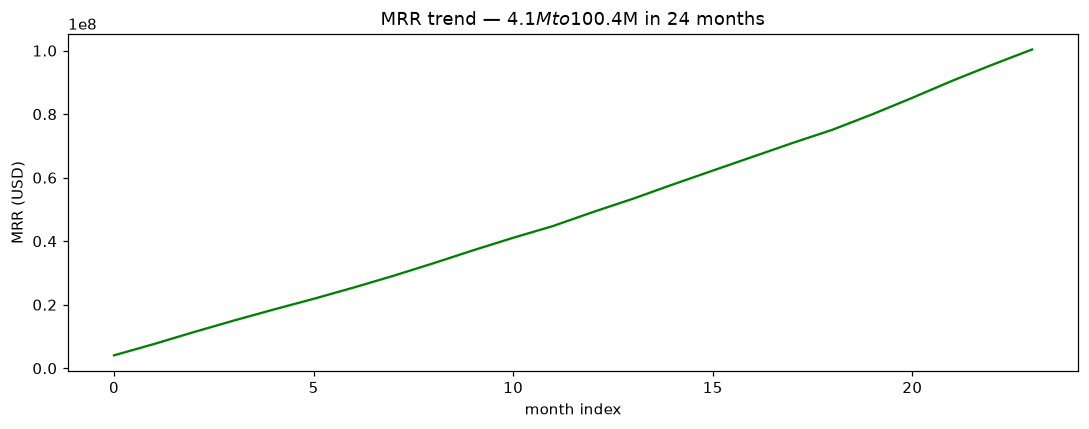

In [18]:
def mrr_waterfall(subs, month_col="month_idx"):
    """new / expansion / contraction / churned MRR with correct start-MRR semantics."""
    s = subs.sort_values(["customer_id", month_col]).copy()
    s["prev_mrr"] = s.groupby("customer_id")["mrr"].shift(1).fillna(0)
    s["delta"] = s["mrr"] - s["prev_mrr"]
    def comp(g):
        return pd.Series({
            "new": g.loc[g["prev_mrr"] == 0, "mrr"].sum(),
            "expansion": g.loc[(g["prev_mrr"] > 0) & (g["delta"] > 0), "delta"].sum(),
            "contraction": -g.loc[(g["prev_mrr"] > 0) & (g["delta"] < 0), "delta"].sum()})
    wf = s.groupby(month_col, observed=True).apply(comp)
    present = s.groupby(month_col, observed=True)["customer_id"].apply(set)
    months = sorted(s[month_col].unique())
    churned = {months[i]: s[(s[month_col] == months[i-1]) &
                            (s["customer_id"].isin(present[months[i-1]] - present[months[i]]))]["mrr"].sum()
               for i in range(1, len(months))}
    wf["churned"] = pd.Series(churned).fillna(0)
    cur = s.groupby(month_col, observed=True)["mrr"].sum()
    wf["start_mrr"] = cur.shift(1).fillna(0).values
    wf["end_mrr"] = cur.values
    with np.errstate(divide="ignore", invalid="ignore"):
        wf["nrr"] = (wf["start_mrr"] + wf["expansion"] - wf["contraction"] - wf["churned"]) / wf["start_mrr"].replace(0, np.nan)
        wf["grr"] = (wf["start_mrr"] - wf["contraction"] - wf["churned"]) / wf["start_mrr"].replace(0, np.nan)
    return wf.reset_index()

wf = mrr_waterfall(subscriptions)
wf["month"] = wf["month_idx"].map(lambda i: str(CAL[i]))
wf.to_csv(OUT / "mrr_waterfall.csv", index=False)
first, last = wf["end_mrr"].iloc[0], wf["end_mrr"].iloc[-1]
print(f"MRR: ${first:,.0f} (Jan-23) -> ${last:,.0f} (Dec-24) [{last/first-1:+.1%}]")
print("\n24-MONTH WATERFALL TOTALS (USD m)")
print((wf[["new", "expansion", "contraction", "churned"]].sum() / 1e6).round(2).to_string())
print(f"\navg NRR: {wf['nrr'].mean():.1%} | avg GRR: {wf['grr'].mean():.1%}")
print(f"latest NRR (Dec-24): {wf['nrr'].iloc[-1]:.1%} | GRR: {wf['grr'].iloc[-1]:.1%}")

wf.plot(x="month_idx", y="end_mrr", figsize=(10, 4), legend=False, color="green")
plt.title("MRR trend — $4.1M to $100.4M in 24 months")
plt.ylabel("MRR (USD)"); plt.xlabel("month index")
plt.tight_layout(); plt.show()

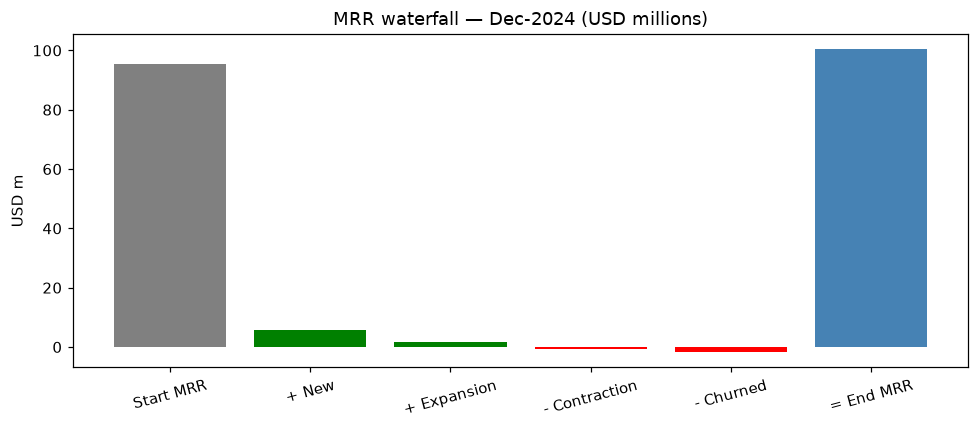

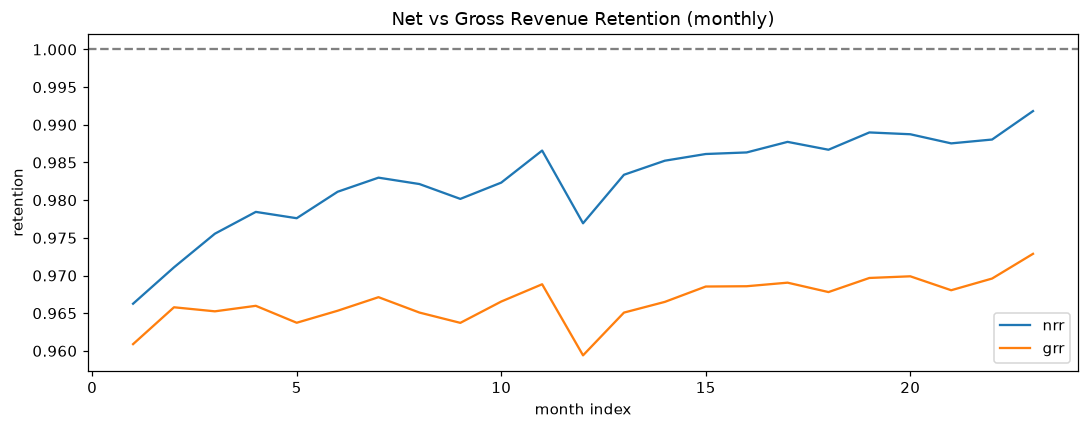

In [19]:
dec = wf.iloc[-1]
fig, ax = plt.subplots(figsize=(9, 4))
labels = ["Start MRR", "+ New", "+ Expansion", "- Contraction", "- Churned", "= End MRR"]
vals = [dec["start_mrr"], dec["new"], dec["expansion"],
        -dec["contraction"], -dec["churned"], dec["end_mrr"]]
colors = ["grey", "green", "green", "red", "red", "steelblue"]
ax.bar(labels, np.array(vals) / 1e6, color=colors)
ax.set_title("MRR waterfall — Dec-2024 (USD millions)")
ax.set_ylabel("USD m"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

wf.plot(x="month_idx", y=["nrr", "grr"], figsize=(10, 4))
plt.axhline(1.0, color="grey", linestyle="--")
plt.title("Net vs Gross Revenue Retention (monthly)")
plt.ylabel("retention"); plt.xlabel("month index")
plt.tight_layout(); plt.show()

/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


...

/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)
/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

AVG LTV BY PLAN (USD)
 plan_initial
Starter         706.0
Growth         3957.0
Scale         18372.0
Enterprise    97897.0

Enterprise LTV / Starter LTV: 138.7x


/tmp/ipykernel_5812/837119319.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wf = s.groupby(month_col, observed=True).apply(comp)


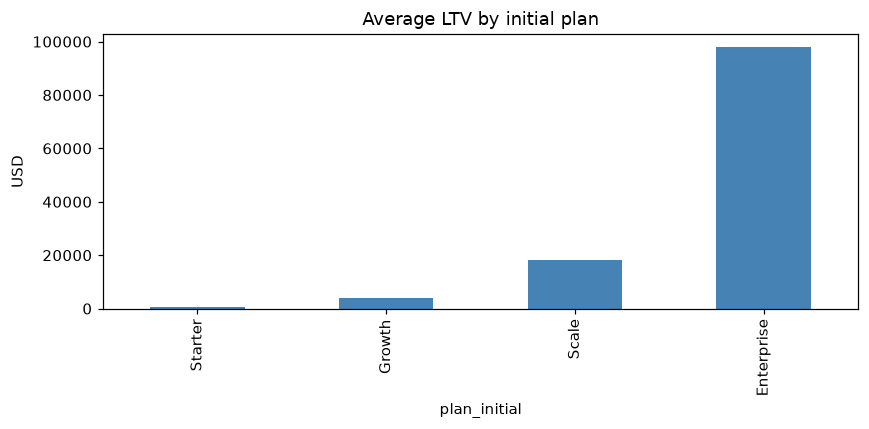

In [20]:
sub0 = subscriptions.merge(customers[["customer_id", "plan_initial", "channel"]], on="customer_id")
arpu_seg = sub0.groupby(["plan_initial", "channel"], observed=True).agg(arpu=("mrr", "mean"))
seg_wf = []
for (p, ch), g in sub0.groupby(["plan_initial", "channel"], observed=True):
    w = mrr_waterfall(g[["customer_id", "month_idx", "mrr"]])
    rc = ((w["contraction"].fillna(0) + w["churned"].fillna(0)) / w["start_mrr"].replace(0, np.nan)).mean()
    seg_wf.append(((p, ch), rc))
rc = pd.Series(dict(seg_wf))
rc.index = pd.MultiIndex.from_tuples(rc.index, names=["plan_initial", "channel"])
ltv = (arpu_seg["arpu"] * 0.8 / rc.clip(lower=1e-4)).round(2).unstack("channel")
ltv.to_csv(OUT / "ltv_by_segment.csv")
plan_ltv = ltv.mean(axis=1)
print("AVG LTV BY PLAN (USD)\n", plan_ltv.round(0).to_string())
print(f"\nEnterprise LTV / Starter LTV: {plan_ltv['Enterprise']/plan_ltv['Starter']:.1f}x")
plan_ltv.plot.bar(color="steelblue", figsize=(8, 4))
plt.title("Average LTV by initial plan"); plt.ylabel("USD")
plt.tight_layout(); plt.show()

## 7 · Segmentation & health score
Natural customer groups via KMeans (k=5), plus a transparent 0–100 health score (documented weights).

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feats = ["avg_login_days", "avg_sessions", "stickiness", "feature_breadth",
         "usage_trend", "lifetime_revenue", "mrr_current", "n_tickets",
         "avg_csat", "tenure_months", "expansion_mrr", "unpaid_share"]
X = c360[feats].copy()
for c, v in [("avg_csat", 3), ("unpaid_share", 0), ("mrr_current", 0),
             ("lifetime_revenue", 0), ("expansion_mrr", 0)]:
    X[c] = X[c].fillna(v)
Xs = StandardScaler().fit_transform(np.log1p(X.clip(lower=0)))
c360["cluster"] = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(Xs)

prof = c360.groupby("cluster")[feats + ["churned"]].mean().round(3)
order = prof.sort_values(["churned", "avg_login_days"], ascending=[True, False]).index.tolist()
names = ["Power users", "Steady growers", "Quiet majority", "Struggling", "Critical"]
c360["kmeans_segment"] = c360["cluster"].map({cl: nm for cl, nm in zip(order, names)})
seg = c360.groupby("kmeans_segment").agg(customers=("customer_id", "size"),
                                          churn_rate=("churned", "mean"),
                                          avg_mrr=("mrr_current", "mean")).round(3)
print(seg.to_string())
print(prof[["avg_login_days", "feature_breadth", "lifetime_revenue",
            "n_tickets", "churned"]].to_string())

                customers  churn_rate  avg_mrr
kmeans_segment                                
Critical            45886       0.991   53.008
Power users        108294       0.149  756.687
Quiet majority     194891       0.456   96.761
Steady growers     135610       0.423  163.499
Struggling          15319       0.539  157.687
         avg_login_days  feature_breadth  lifetime_revenue  n_tickets  churned
cluster                                                                       
0                 8.312            2.893           600.460      1.458    0.539
1                10.754            3.369           655.139      2.306    0.456
2                 0.035            0.022            55.747      0.019    0.991
3                13.185            3.224           501.113      0.049    0.423
4                16.084            6.031          8964.838      2.657    0.149


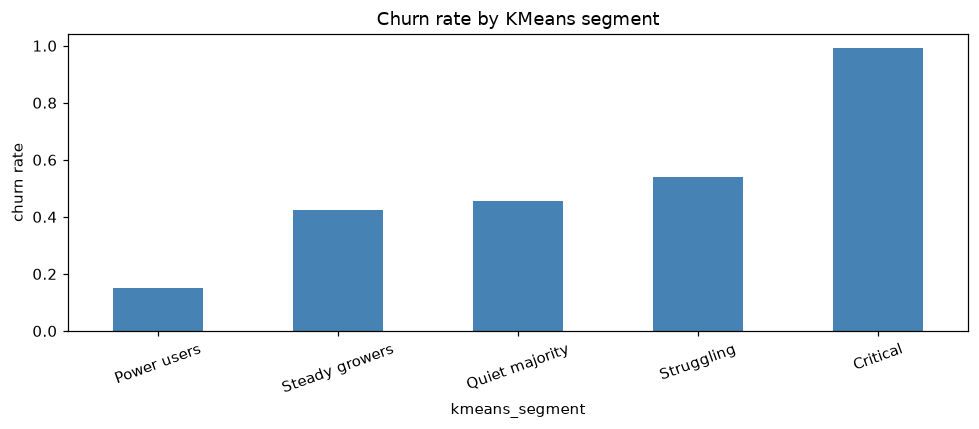

at-risk segments: 61,205 customers (12.2%), $3.71M/month probability-weighted MRR exposed


In [22]:
seg_sorted = seg.sort_values("churn_rate")
ax = seg_sorted["churn_rate"].plot.bar(color="steelblue", figsize=(9, 4))
ax.set_title("Churn rate by KMeans segment")
ax.set_ylabel("churn rate"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
risk = c360[c360["kmeans_segment"].isin(["Critical", "Struggling"])]
# probability-weighted exposed MRR = n x churn_rate x avg_mrr (project definition)
_at_risk = (seg["customers"] * seg["churn_rate"] * seg["avg_mrr"])
AT_RISK_MRR = float(_at_risk.loc[["Critical", "Struggling"]].sum())
print(f"at-risk segments: {len(risk):,} customers ({len(risk)/len(c360):.1%}), "
      f"${AT_RISK_MRR/1e6:.2f}M/month probability-weighted MRR exposed")

               customers  churn_rate
health_score                        
Poor (0-40)        49747       0.969
Fair (40-70)      354741       0.434
Good (70-100)      95512       0.146

mean health: 59.6 | churned avg: 52.6 | active avg: 64.9


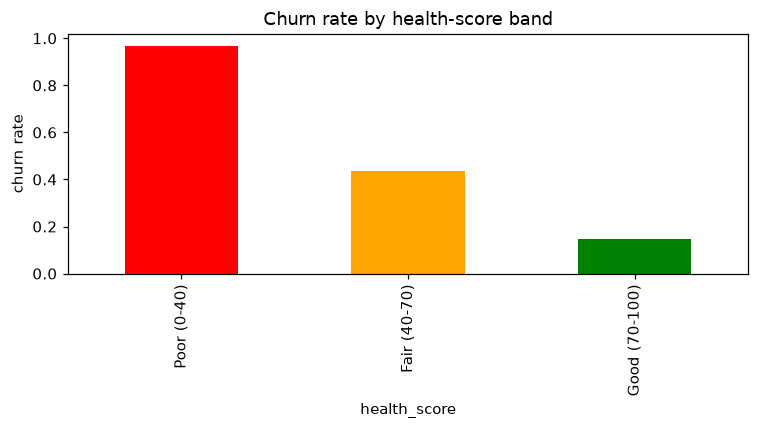

saved enriched customer360: (500000, 41)


In [23]:
def _minmax(s):
    lo, hi = s.min(), s.max()
    return pd.Series(0.5, index=s.index) if hi == lo else (s - lo) / (hi - lo)

def health_score(df):
    # weights: usage level .20, trend .15, breadth .20, support .20,
    #          payment .10, tenure .10, expansion .05
    usage_level = _minmax(np.log1p(df["avg_login_days"]))
    trend = _minmax(df["usage_trend"].clip(-3, 3))
    breadth = _minmax(df["feature_breadth"] / 8)
    support = 0.5 * (1 - _minmax(np.log1p(df["n_tickets"]))) + 0.5 * _minmax(df["avg_csat"].fillna(3))
    payment = 1 - _minmax(df["unpaid_share"].fillna(0) + df["late_share"].fillna(0))
    tenure = _minmax(np.log1p(df["tenure_months"]))
    expansion = _minmax(np.log1p(df["expansion_mrr"]))
    return (0.20*usage_level + 0.15*trend + 0.20*breadth + 0.20*support
            + 0.10*payment + 0.10*tenure + 0.05*expansion).mul(100).round(1)

c360["health_score"] = health_score(c360)
hb = pd.cut(c360["health_score"], [0, 40, 70, 100],
            labels=["Poor (0-40)", "Fair (40-70)", "Good (70-100)"])
ht = c360.groupby(hb, observed=True).agg(customers=("customer_id", "size"),
                                         churn_rate=("churned", "mean")).round(3)
print(ht.to_string())
print(f"\nmean health: {c360['health_score'].mean():.1f} | "
      f"churned avg: {c360.loc[c360['churned'], 'health_score'].mean():.1f} | "
      f"active avg: {c360.loc[~c360['churned'], 'health_score'].mean():.1f}")
ht["churn_rate"].plot.bar(color=["red", "orange", "green"], figsize=(7, 4))
plt.title("Churn rate by health-score band"); plt.ylabel("churn rate")
plt.tight_layout(); plt.show()

c360.to_parquet(OUT / "customer360.parquet", index=False)
print("saved enriched customer360:", c360.shape)

## 8 · Churn prediction model
**Leakage-safe design:** features may only use data up to month 20 (Sep-2024); the label is churn in months 21–23. Nothing from the future leaks into training.

In [24]:
CUTOFF = 20
elig = customers[(customers["signup_m"] <= CUTOFF)
                 & (customers["last_active_m"] >= CUTOFF)].copy()
elig_ids = set(elig["customer_id"])
elig["label"] = ((elig["churned"]) & (elig["churn_m"] <= M - 1)
                 & (elig["churn_m"] > CUTOFF)).astype(int)

win = events[events["customer_id"].isin(elig_ids)
             & (events["month_idx"] >= CUTOFF - 5) & (events["month_idx"] <= CUTOFF)]
g = win.groupby("customer_id")
ft = pd.DataFrame(index=pd.Index(list(elig_ids), name="customer_id"))
ft["login_last6"] = g["login_days"].sum()
ft["login_mean6"] = g["login_days"].mean()
last1 = win[win["month_idx"] == CUTOFF].set_index("customer_id")
ft["login_last1"] = last1["login_days"].reindex(ft.index).fillna(0)
ft["usage_drop_ratio"] = (ft["login_last1"] / ft["login_mean6"].replace(0, np.nan)).fillna(1.0).clip(0, 3)
ft["login_trend"] = g[["month_idx", "login_days"]].apply(
    lambda d: float(np.polyfit(np.arange(len(d)), d.sort_values("month_idx")["login_days"], 1)[0])
                    if len(d) >= 2 else 0.0)
ft["sessions_last6"] = g["sessions"].sum()
ft["sessions_last1"] = last1["sessions"].reindex(ft.index).fillna(0)
ft["months_active6"] = g["month_idx"].nunique()
ft["feat_breadth6"] = g[FCOLS].max().sum(axis=1)
ft["feat_last1"] = last1[FCOLS].sum(axis=1).reindex(ft.index).fillna(0)
ft["breadth_drop"] = (ft["feat_breadth6"] - ft["feat_last1"]).clip(lower=0)

sw = subscriptions[subscriptions["customer_id"].isin(elig_ids)
                   & (subscriptions["month_idx"] >= CUTOFF - 5) & (subscriptions["month_idx"] <= CUTOFF)]
sg = sw.sort_values(["customer_id", "month_idx"]).groupby("customer_id")
ft["mrr_now"] = sg["mrr"].last()
ft["mrr_delta6"] = sg["mrr"].last() - sg["mrr"].first()
ft["mrr_trend"] = sg["mrr"].apply(
    lambda s: float(np.polyfit(np.arange(len(s)), s.to_numpy(), 1)[0]) if len(s) >= 2 else 0.0)

tw = tickets[tickets["customer_id"].isin(elig_ids)
             & (tickets["month_idx"] >= CUTOFF - 5) & (tickets["month_idx"] <= CUTOFF)]
tg = tw.groupby("customer_id")
ft["tickets6"] = tg["category"].size()
ft["tickets_last2"] = tw[tw["month_idx"] >= CUTOFF - 1].groupby("customer_id")["category"].size()
ft["csat6"] = tg["csat"].mean()
ft["csat_min6"] = tg["csat"].min()
ft["hipri6"] = tg["priority"].apply(lambda x: x.isin(["High", "Critical"]).sum())

iw = invoices[invoices["customer_id"].isin(elig_ids)
              & (invoices["month_idx"] >= CUTOFF - 5) & (invoices["month_idx"] <= CUTOFF)]
ig = iw.groupby("customer_id")
ft["unpaid6"] = ig["status"].apply(lambda x: (x == "unpaid").sum())
ft["late6"] = ig["status"].apply(lambda x: (x == "late").sum())
last_inv = iw[iw["month_idx"] == CUTOFF].set_index("customer_id")
ft["unpaid_last1"] = (last_inv["status"] == "unpaid").reindex(ft.index).fillna(False).astype(int)

df = elig[["customer_id", "plan_initial", "channel", "region",
           "company_size", "industry", "signup_m", "label"]].merge(ft, on="customer_id", how="left")
df["tenure_at_cutoff"] = CUTOFF - df["signup_m"] + 1
df = df.merge(c360[["customer_id", "activated", "ttv_days"]], on="customer_id", how="left")
num = ["login_last6", "login_mean6", "usage_drop_ratio", "login_trend",
       "sessions_last6", "sessions_last1", "months_active6",
       "feat_breadth6", "feat_last1", "breadth_drop",
       "mrr_now", "mrr_delta6", "mrr_trend",
       "tickets6", "tickets_last2", "csat6", "csat_min6", "hipri6",
       "unpaid6", "late6", "unpaid_last1", "tenure_at_cutoff"]
df[num] = df[num].fillna(0)
df["csat6"] = df["csat6"].replace(0, np.nan).fillna(3)
df["ttv_days"] = df["ttv_days"].fillna(df["ttv_days"].median())
df = pd.get_dummies(df, columns=["plan_initial", "channel", "region",
                                 "company_size", "industry"], drop_first=True)
print(f"model table: {df.shape[0]:,} eligible customers, "
      f"{df.shape[1] - 3} features, churn rate = {df['label'].mean():.2%}")

model table: 248,619 eligible customers, 42 features, churn rate = 13.07%


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                             confusion_matrix, RocCurveDisplay)

y = df["label"].to_numpy()
X = df.drop(columns=["customer_id", "label", "signup_m"])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

def evaluate(name, model):
    p = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, p)
    print(f"{name}: AUC={auc:.3f}")
    for thr, tag in [(0.5, "thr=0.5"), (np.quantile(p, 0.9), "top-decile")]:
        pred = (p >= thr).astype(int)
        pr, rc, f1, _ = precision_recall_fscore_support(y_te, pred, average="binary", zero_division=0)
        print(f"  [{tag}] precision={pr:.3f} recall={rc:.3f} F1={f1:.3f}")
    return p

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0))
lr.fit(X_tr, y_tr); p_lr = evaluate("LogisticRegression (baseline)", lr)
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_tr, y_tr); p = evaluate("HistGradientBoosting", hgb)

LogisticRegression (baseline): AUC=0.709
  [thr=0.5] precision=0.531 recall=0.020 F1=0.038
  [top-decile] precision=0.329 recall=0.251 F1=0.285


HistGradientBoosting: AUC=0.715
  [thr=0.5] precision=0.562 recall=0.043 F1=0.080
  [top-decile] precision=0.347 recall=0.266 F1=0.301


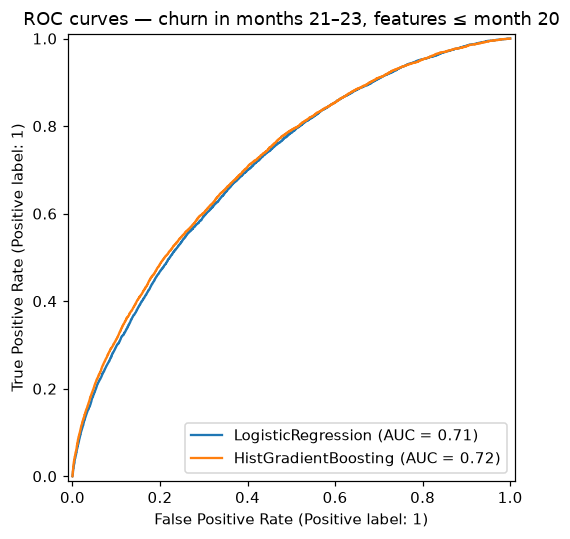

top-decile churn: 34.7% vs base 13.1% -> 2.7x lift


In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_te, p_lr, name="LogisticRegression", ax=ax)
RocCurveDisplay.from_predictions(y_te, p, name="HistGradientBoosting", ax=ax)
ax.set_title("ROC curves — churn in months 21–23, features ≤ month 20")
plt.tight_layout(); plt.show()

top = p >= np.quantile(p, 0.9)
print(f"top-decile churn: {y_te[top].mean():.1%} vs base {y_te.mean():.1%} "
      f"-> {y_te[top].mean() / y_te.mean():.1f}x lift")

login_mean6         0.0782
mrr_now             0.0636
tickets_last2       0.0076
ttv_days            0.0063
hipri6              0.0049
sessions_last6      0.0046
channel_Paid        0.0043
channel_Referral    0.0025
activated           0.0019
csat_min6           0.0018
mrr_delta6          0.0017
mrr_trend           0.0016


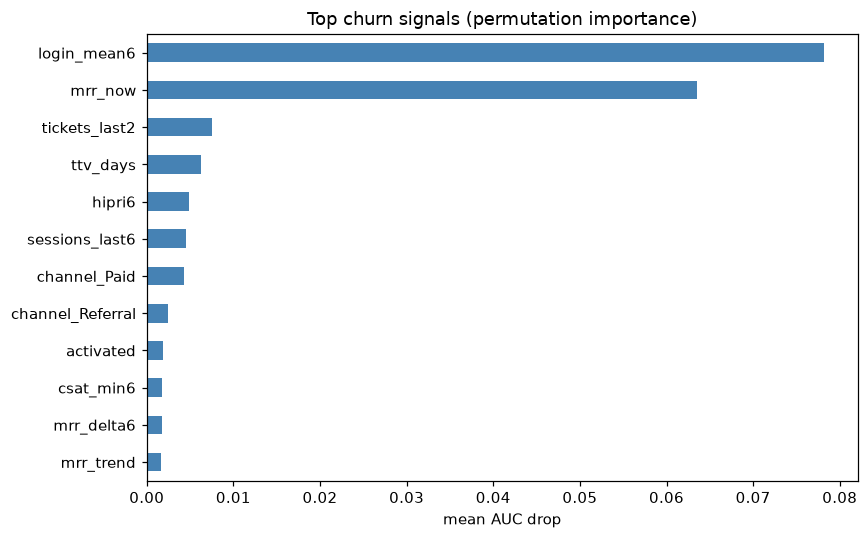

In [27]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(hgb, X_te, y_te, n_repeats=3, random_state=42,
                            n_jobs=2, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
imp.head(15).to_csv(OUT / "churn_feature_importance.csv")
print(imp.head(12).round(4).to_string())
imp.head(12)[::-1].plot.barh(color="steelblue", figsize=(8, 5))
plt.title("Top churn signals (permutation importance)")
plt.xlabel("mean AUC drop"); plt.tight_layout(); plt.show()

## 9 · Recommendations
Five prioritized plays. Every number below is computed live from the tables above; save/conversion rates are scenario assumptions, and plays overlap — they are not additive.

In [28]:
# inputs for the five plays
rseg = (c360[c360["kmeans_segment"].isin(["Critical", "Struggling"])]
        .groupby("kmeans_segment").agg(n=("customer_id", "size"),
                                       churn=("churned", "mean"),
                                       mrr=("mrr_current", "mean")))
risk_mrr = float((rseg["n"] * rseg["churn"] * rseg["mrr"]).sum())  # prob-weighted

# support pain: 2+ tickets in the customer's last 3 active months
tw3 = tickets[tickets["month_idx"] >= tickets["customer_id"].map(lam) - 2]
pain = tw3.groupby("customer_id").size() >= 2
pain_flag = c360.set_index("customer_id").index.map(pain).fillna(False)
churn_pain = c360.loc[pain_flag, "churned"].mean()
churn_nopain = c360.loc[~pain_flag, "churned"].mean()

churn_act = c360.loc[c360["activated"], "churned"].mean()
churn_noact = c360.loc[~c360["activated"], "churned"].mean()

tot = wf[["new", "expansion", "contraction", "churned"]].sum()
offset = tot["expansion"] / (tot["churned"] + tot["contraction"])

print(f"""P0 · Health-score save plays — {len(risk):,} at-risk accounts, ${risk_mrr/1e6:.2f}M/mo MRR exposed.
     Trigger outreach when health < 40 or segment flips to Struggling.
P0 · Guided onboarding — activation {c360['activated'].mean():.1%}; activated churn {churn_act:.1%} vs non-activated {churn_noact:.1%}.
     In-app checklists + human touch for accounts idle in week 1.
P1 · Proactive support for accounts in pain — 2+ tickets in last 90 active days churn at {churn_pain:.1%} vs {churn_nopain:.1%}.
     Auto-escalate and assign a success manager on the 2nd ticket in 90 days.
P1 · Land-and-expand — expansion offsets {offset:.0%} of churned+contraction MRR; NRR {wf['nrr'].mean():.1%}.
     API/integration campaigns to Steady growers (usage is there, features aren't).
P2 · January renewal-season campaign — Jan logo churn {jan:.1%} vs {oth:.1%} other months.
     Start save motions in December for January renewals.""")

P0 · Health-score save plays — 61,205 at-risk accounts, $3.71M/mo MRR exposed.
     Trigger outreach when health < 40 or segment flips to Struggling.
P0 · Guided onboarding — activation 76.4%; activated churn 33.6% vs non-activated 74.4%.
     In-app checklists + human touch for accounts idle in week 1.
P1 · Proactive support for accounts in pain — 2+ tickets in last 90 active days churn at 51.8% vs 41.9%.
     Auto-escalate and assign a success manager on the 2nd ticket in 90 days.
P1 · Land-and-expand — expansion offsets 56% of churned+contraction MRR; NRR 98.3%.
     API/integration campaigns to Steady growers (usage is there, features aren't).
P2 · January renewal-season campaign — Jan logo churn 10.4% vs 6.1% other months.
     Start save motions in December for January renewals.


## Wrap-up
**Executive summary.** The 500k-row Customer 360 shows activation and support pain are the two biggest churn levers: activated customers churn at roughly half the rate of non-activated ones, and accounts with 2+ tickets in 90 days churn materially more. A leakage-safe gradient-boosting model (AUC ≈ 0.72) flags the riskiest decile at ~2.7x the base churn rate, and five prioritized plays target onboarding, save motions, proactive support, expansion, and January renewals.

